In [114]:
import math, copy
import numpy as np
import matplotlib.pyplot as plt

In [115]:
def zscore_normalize(x):
    mu = x.mean(axis=0)
    sigma = x.std(axis=0)
    X_norm = (x - mu)/sigma
    return X_norm

In [116]:
x = np.arange(0, 20, 1)
y = x**2
X = np.c_[x, x**2, x**3]
print(np.ptp(X, axis=0))
X = zscore_normalize(X)
y = zscore_normalize(y)
print(np.ptp(X, axis=0))

[  19  361 6859]
[3.29501788 3.18076489 3.28307153]


In [117]:
def compute_cost(x, y, w, b):
    f_wb = (np.dot(x,w) + b )
    cost = (f_wb - y)**2
    total_cost = cost.mean()/2
    return total_cost

In [118]:

def compute_gradient(x, y, w, b):
    m = x.shape[0]
    f_wb = (np.dot(x,w) + b)
    error = (f_wb - y)
    dj_dw = (1/m)*(x.T@error)
    dj_db = error.mean()
    return dj_dw, dj_db

In [119]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iter, cost_func, gradient_func):
    w = copy.deepcopy(w_in)
    b = b_in
    j_history = []
    
    for i in range(num_iter):
        dj_dw, dj_db = gradient_func(x, y, w, b)
        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        if i<(1000):
            j_history.append(cost_func(x,y,w,b))

        if i% math.ceil(num_iter / 10)==0:
            print(f"Iteration: {i:<8} cost:{j_history[-1]:12.6f}")

    return w,b, j_history

In [120]:
n = X.shape[1]
initial_w = np.zeros((n))
print(X)
initial_b = 0
alpha = 1e-1
iterations = 1000
w_final, b_final, cost = gradient_descent(X, y, initial_w, initial_b, alpha, iterations, compute_cost, compute_gradient)
print(f"w: {w_final}, b: {b_final}")

[[-1.64750894 -1.08815641 -0.86396619]
 [-1.47408695 -1.07934543 -0.86348754]
 [-1.30066495 -1.05291248 -0.86013698]
 [-1.12724296 -1.00885756 -0.8510426 ]
 [-0.95382097 -0.94718068 -0.83333249]
 [-0.78039897 -0.86788183 -0.80413474]
 [-0.60697698 -0.77096102 -0.76057744]
 [-0.43355498 -0.65641824 -0.69978868]
 [-0.26013299 -0.52425349 -0.61889656]
 [-0.086711   -0.37446678 -0.51502915]
 [ 0.086711   -0.2070581  -0.38531456]
 [ 0.26013299 -0.02202746 -0.22688087]
 [ 0.43355498  0.18062515 -0.03685618]
 [ 0.60697698  0.40089973  0.18763144]
 [ 0.78039897  0.63879627  0.44945388]
 [ 0.95382097  0.89431478  0.75148306]
 [ 1.12724296  1.16745526  1.09659088]
 [ 1.30066495  1.4582177   1.48764927]
 [ 1.47408695  1.76660211  1.92753011]
 [ 1.64750894  2.09260848  2.41910534]]
Iteration: 0        cost:    0.251867
Iteration: 100      cost:    0.000498
Iteration: 200      cost:    0.000418
Iteration: 300      cost:    0.000396
Iteration: 400      cost:    0.000384
Iteration: 500      cost:    

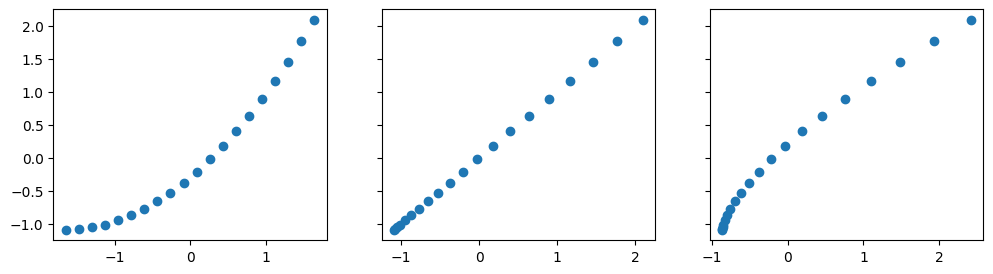

In [121]:
fig, ax = plt.subplots(1, 3, figsize=(12,3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X[:,i], y)